In [1]:
%pip install torch torchvision pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [3]:
class FolderYoloDataset(Dataset):
    def __init__(self, split_root, transform=None):
        self.split_root = split_root
        self.images_dir = os.path.join(split_root, "images")
        self.labels_dir = os.path.join(split_root, "labels")
        self.transform = transform

        # Collect all label files
        self.label_files = sorted(
            [
                os.path.join(self.labels_dir, f)
                for f in os.listdir(self.labels_dir)
                if f.endswith(".txt")
            ]
        )

    def __len__(self):
        return len(self.label_files)

    def _find_image_path(self, label_path):
        stem = os.path.splitext(os.path.basename(label_path))[0]
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            img_path = os.path.join(self.images_dir, stem + ext)
            if os.path.exists(img_path):
                return img_path
        raise FileNotFoundError(f"No image found for label file: {label_path}")

    def __getitem__(self, idx):
        label_path = self.label_files[idx]
        img_path = self._find_image_path(label_path)
        class_ids = []
        with open(label_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                class_id = int(parts[0])
                class_ids.append(class_id)

        if not class_ids:
            label = 1
        else:
            label = 0 if any(cid == 0 for cid in class_ids) else 1

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

# Data augmentation and normalization
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Root directory
root_dir = r"c:\Users\user\Documents\Computer vision\data"

train_root = os.path.join(root_dir, "train")
val_root   = os.path.join(root_dir, "valid")
# test_root  = os.path.join(root_dir, "test")  # optional, for later use

train_dataset = FolderYoloDataset(train_root, transform=train_transform)
val_dataset   = FolderYoloDataset(val_root,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

len(train_dataset), len(val_dataset)


(291, 71)

In [4]:
# CNN model
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),  # output 1 logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)  # [B]

model = SimpleCNN()
model

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout

In [5]:
# Training and validation (with history recording)
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
val_accuracies = []

def evaluate(model, loader):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()  # >=0.5 → label 1 (normal)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_dataset)
    val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/20, Train Loss: 0.4326, Val Acc: 0.8873
Epoch 2/20, Train Loss: 0.1824, Val Acc: 0.9577
Epoch 3/20, Train Loss: 0.1083, Val Acc: 0.9718
Epoch 4/20, Train Loss: 0.0592, Val Acc: 1.0000
Epoch 5/20, Train Loss: 0.0501, Val Acc: 0.9859
Epoch 6/20, Train Loss: 0.0452, Val Acc: 1.0000
Epoch 7/20, Train Loss: 0.0309, Val Acc: 1.0000
Epoch 8/20, Train Loss: 0.0319, Val Acc: 1.0000
Epoch 9/20, Train Loss: 0.0257, Val Acc: 1.0000
Epoch 10/20, Train Loss: 0.0045, Val Acc: 1.0000
Epoch 11/20, Train Loss: 0.0015, Val Acc: 1.0000
Epoch 12/20, Train Loss: 0.0051, Val Acc: 1.0000
Epoch 13/20, Train Loss: 0.0029, Val Acc: 1.0000
Epoch 14/20, Train Loss: 0.0016, Val Acc: 1.0000
Epoch 15/20, Train Loss: 0.0025, Val Acc: 1.0000
Epoch 16/20, Train Loss: 0.0010, Val Acc: 1.0000
Epoch 17/20, Train Loss: 0.0028, Val Acc: 1.0000
Epoch 18/20, Train Loss: 0.0006, Val Acc: 1.0000
Epoch 19/20, Train Loss: 0.0005, Val Acc: 1.0000
Epoch 20/20, Train Loss: 0.0010, Val Acc: 1.0000


In [6]:
# Save model after training
import os

project_root = r"C:\Users\user\Documents\Computer vision"

model_dir = os.path.join(project_root, "cnn")
os.makedirs(model_dir, exist_ok=True) 

model_path = os.path.join(model_dir, "defect_cnn.pth")
torch.save(model.state_dict(), model_path)

print("Saved the model:", model_path)

Saved the model: C:\Users\user\Documents\Computer vision\cnn\defect_cnn.pth


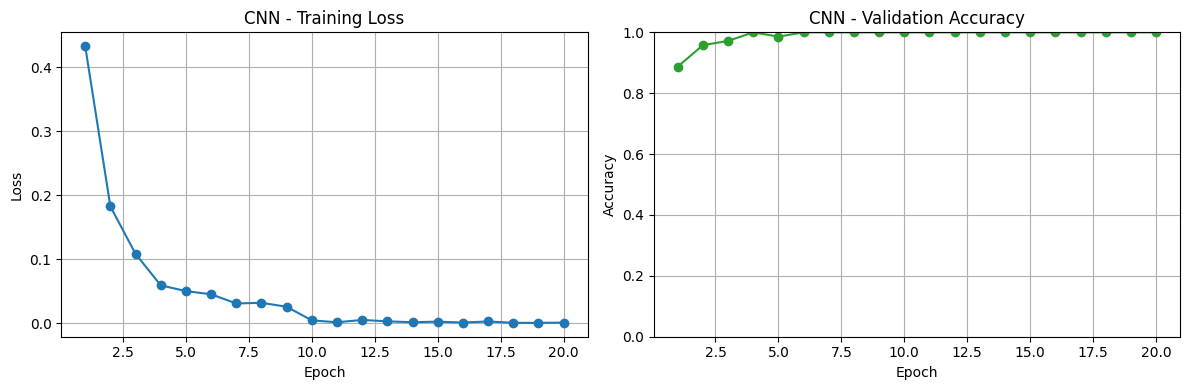

In [7]:
# Visualize training history: loss and validation accuracy
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker="o", color="tab:blue")
plt.title("CNN - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, marker="o", color="tab:green")
plt.title("CNN - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()